In [1]:
import pickle
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

C:\Users\noton\miniconda3\envs\Deep2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = GCNConv(30, 256)
        self.conv2 = GCNConv(256, 256)
        self.conv3 = GCNConv(256, 256)
        self.conv4 = GCNConv(256, 256)
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = F.relu(x)
        x = global_max_pool(x, data.batch)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

In [3]:
def custom_collate(batch):
    data_list, target_list = zip(*batch)
    batch_data = Batch.from_data_list(data_list)
    batch_target = torch.stack(target_list)
    return batch_data, batch_target

Dataset :  AI+Human
Epoch 1, Validation Loss: 0.34083643093355326
Epoch 2, Validation Loss: 0.23907248231661204
Epoch 3, Validation Loss: 0.17734881311700748
Epoch 4, Validation Loss: 0.1571552668800728
Epoch 5, Validation Loss: 0.13033819682214656
Epoch 6, Validation Loss: 0.11846420278650766
Epoch 7, Validation Loss: 0.12028794841227462
Epoch 8, Validation Loss: 0.10966315625183953
Epoch 9, Validation Loss: 0.07734666785356059
Epoch 10, Validation Loss: 0.06554478527929435
Epoch 11, Validation Loss: 0.06219086749016353
Epoch 12, Validation Loss: 0.06063281548426345
Epoch 13, Validation Loss: 0.058161481248109624
Epoch 14, Validation Loss: 0.06111297068867347
Epoch 15, Validation Loss: 0.05938817078213184
Epoch 16, Validation Loss: 0.05711835396553658
Epoch 17, Validation Loss: 0.05148809865684565
Epoch 18, Validation Loss: 0.048240618127890836
Epoch 19, Validation Loss: 0.04708254104996019
Epoch 20, Validation Loss: 0.048112607299504825
Epoch 21, Validation Loss: 0.044758248366038714

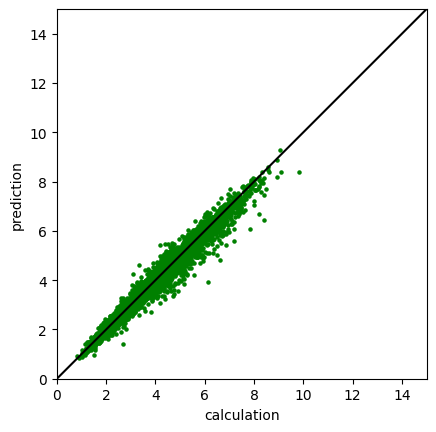

Dataset :  AI2+Human
Epoch 1, Validation Loss: 0.33973621553951117
Epoch 2, Validation Loss: 0.19866531941975357
Epoch 3, Validation Loss: 0.16764475957536723
Epoch 4, Validation Loss: 0.12470610492329533
Epoch 5, Validation Loss: 0.09852400342659293
Epoch 6, Validation Loss: 0.07573497223092006
Epoch 7, Validation Loss: 0.06992919693356767
Epoch 8, Validation Loss: 0.062094561483386705
Epoch 9, Validation Loss: 0.05668373925416996
Epoch 10, Validation Loss: 0.05829985157897408
Epoch 11, Validation Loss: 0.05743426083379289
Epoch 12, Validation Loss: 0.06469576009038149
Epoch 13, Validation Loss: 0.061877605395045186
Epoch 14, Validation Loss: 0.04075869452446023
Epoch 15, Validation Loss: 0.03699072978191691
Epoch 16, Validation Loss: 0.03603238985898458
Epoch 17, Validation Loss: 0.0371452935562071
Epoch 18, Validation Loss: 0.03592471814772772
Epoch 19, Validation Loss: 0.03152745610161439
Epoch 20, Validation Loss: 0.03215537985956991
Epoch 21, Validation Loss: 0.03238386358593911


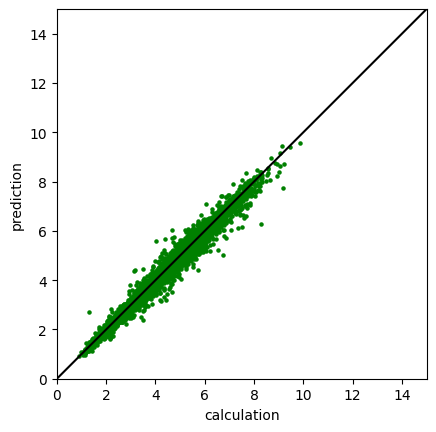

Dataset :  Random+Human
Epoch 1, Validation Loss: 0.3369433894915973
Epoch 2, Validation Loss: 0.229164371145727
Epoch 3, Validation Loss: 0.16733054051343035
Epoch 4, Validation Loss: 0.1619581670306861
Epoch 5, Validation Loss: 0.11285070966531939
Epoch 6, Validation Loss: 0.08915876144004821
Epoch 7, Validation Loss: 0.07641761595838932
Epoch 8, Validation Loss: 0.08082267075030707
Epoch 9, Validation Loss: 0.06215614041589352
Epoch 10, Validation Loss: 0.056383160701986394
Epoch 11, Validation Loss: 0.05474559675409623
Epoch 12, Validation Loss: 0.050925911111993315
Epoch 13, Validation Loss: 0.05176672394196166
Epoch 14, Validation Loss: 0.052893398211095836
Epoch 15, Validation Loss: 0.04830548647434418
Epoch 16, Validation Loss: 0.049680382867797745
Epoch 17, Validation Loss: 0.045140628433028754
Epoch 18, Validation Loss: 0.04341475657312776
Epoch 19, Validation Loss: 0.04592429654328586
Epoch 20, Validation Loss: 0.04306010795265194
Epoch 21, Validation Loss: 0.044085671162600

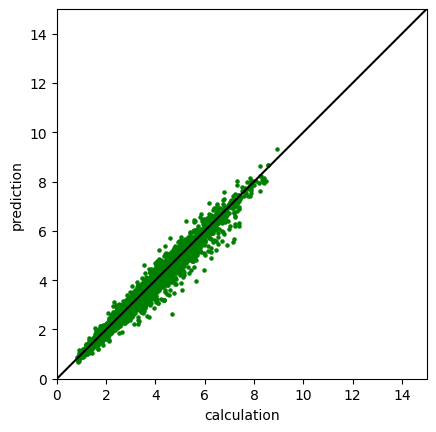

Dataset :  AI+Random
Epoch 1, Validation Loss: 0.2017529084959578
Epoch 2, Validation Loss: 0.14303599537865944
Epoch 3, Validation Loss: 0.10286713034329206
Epoch 4, Validation Loss: 0.08894014164869254
Epoch 5, Validation Loss: 0.083107532584713
Epoch 6, Validation Loss: 0.07621354694565403
Epoch 7, Validation Loss: 0.07437961826278655
Epoch 8, Validation Loss: 0.06839104875576688
Epoch 9, Validation Loss: 0.06592377812411183
Epoch 10, Validation Loss: 0.06133118347403545
Epoch 11, Validation Loss: 0.06142768062120605
Epoch 12, Validation Loss: 0.058411423508437046
Epoch 13, Validation Loss: 0.057048732456043
Epoch 14, Validation Loss: 0.056836632120070646
Epoch 15, Validation Loss: 0.05668696437051951
Epoch 16, Validation Loss: 0.050916758220558266
Epoch 17, Validation Loss: 0.04885591108756316
Epoch 18, Validation Loss: 0.04794350879300838
Epoch 19, Validation Loss: 0.04491794898735614
Epoch 20, Validation Loss: 0.04385266567960167
Epoch 21, Validation Loss: 0.042574159115722175
Ep

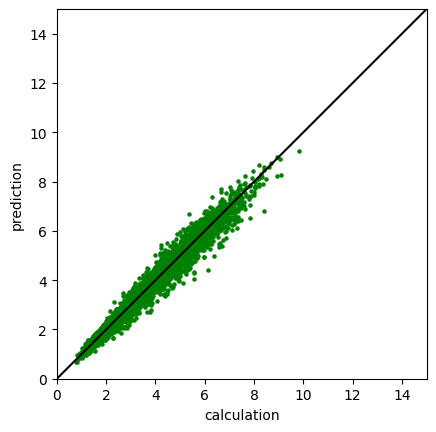

Dataset :  AI2+Random
Epoch 1, Validation Loss: 0.2116616346152898
Epoch 2, Validation Loss: 0.19321628866885138
Epoch 3, Validation Loss: 0.10201641316549812
Epoch 4, Validation Loss: 0.08738832538202221
Epoch 5, Validation Loss: 0.0783010500705226
Epoch 6, Validation Loss: 0.07399337039676433
Epoch 7, Validation Loss: 0.07284257655182765
Epoch 8, Validation Loss: 0.0688469237146231
Epoch 9, Validation Loss: 0.07250804724614036
Epoch 10, Validation Loss: 0.05998075229612272
Epoch 11, Validation Loss: 0.059207504128609714
Epoch 12, Validation Loss: 0.05859941626059565
Epoch 13, Validation Loss: 0.053819539314016375
Epoch 14, Validation Loss: 0.05525068931733254
Epoch 15, Validation Loss: 0.053721144320591434
Epoch 16, Validation Loss: 0.05234043751376106
Epoch 17, Validation Loss: 0.05092005362942408
Epoch 18, Validation Loss: 0.044488939286881427
Epoch 19, Validation Loss: 0.04830817598437644
Epoch 20, Validation Loss: 0.04495429694423122
Epoch 21, Validation Loss: 0.04352767728860453

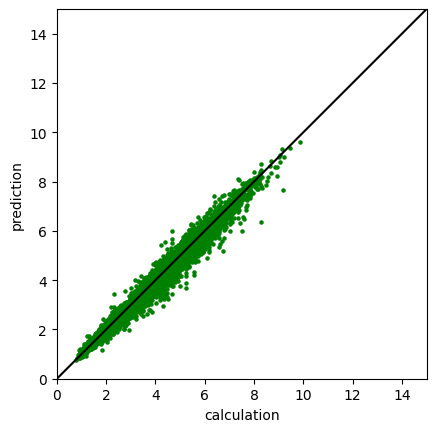

Dataset :  AI+AI2
Epoch 1, Validation Loss: 0.22201628417018418
Epoch 2, Validation Loss: 0.16721251855161678
Epoch 3, Validation Loss: 0.12626015589684342
Epoch 4, Validation Loss: 0.11124725444386713
Epoch 5, Validation Loss: 0.09150247731620438
Epoch 6, Validation Loss: 0.07562026290674904
Epoch 7, Validation Loss: 0.06877842940113879
Epoch 8, Validation Loss: 0.06348575016569699
Epoch 9, Validation Loss: 0.05967911917466682
Epoch 10, Validation Loss: 0.054980623113320075
Epoch 11, Validation Loss: 0.0527388869856876
Epoch 12, Validation Loss: 0.05068934348019383
Epoch 13, Validation Loss: 0.04981405648662293
Epoch 14, Validation Loss: 0.04696965920486986
Epoch 15, Validation Loss: 0.0462642753632904
Epoch 16, Validation Loss: 0.04281713680724358
Epoch 17, Validation Loss: 0.04233915329983491
Epoch 18, Validation Loss: 0.042865589002959135
Epoch 19, Validation Loss: 0.044157251723532326
Epoch 20, Validation Loss: 0.04166940450804836
Epoch 21, Validation Loss: 0.03873124048593795
Epo

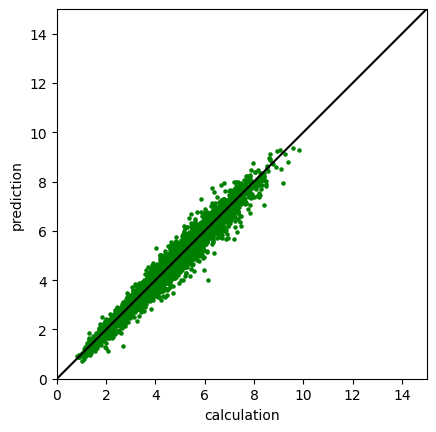

In [4]:
torch.manual_seed(0)

target_data = "kappa3"
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
    
for d in ["AI+Human", "AI2+Human", "Random+Human", "AI+Random", "AI2+Random", "AI+AI2"]:
    torch.manual_seed(0)
    print('Dataset : ', d)
    dataset = d

    with open(f'data_{dataset}/data_train_list.pkl', 'rb') as f:
        data_train_list = pickle.load(f)
    with open(f'data_{dataset}/data_val_list.pkl', 'rb') as f:
        data_val_list = pickle.load(f)
    with open(f'data_{dataset}/data_test_list.pkl', 'rb') as f:
        data_test_list = pickle.load(f)
    with open(f'data_{dataset}/target_train_{target_data}.pkl', 'rb') as f:
        target_train = pickle.load(f)
    with open(f'data_{dataset}/target_val_{target_data}.pkl', 'rb') as f:
        target_val = pickle.load(f)
    with open(f'data_{dataset}/target_test_{target_data}.pkl', 'rb') as f:
        target_test = pickle.load(f)
    
    scaler = StandardScaler()
    target_train = scaler.fit_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_val = scaler.transform(np.array(target_val).reshape(-1, 1)).flatten()
    target_test = scaler.transform(np.array(target_test).reshape(-1, 1)).flatten()
    target_train = torch.tensor(target_train, dtype=torch.float32)
    target_val = torch.tensor(target_val, dtype=torch.float32)
    target_test = torch.tensor(target_test, dtype=torch.float32)

    train_loader = DataLoader(list(zip(data_train_list, target_train)), batch_size=128, collate_fn=custom_collate)
    val_loader = DataLoader(list(zip(data_val_list, target_val)), batch_size=128, collate_fn=custom_collate)
    test_loader = DataLoader(list(zip(data_test_list, target_test)), batch_size=128, collate_fn=custom_collate)

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    early_stopping_patience = 30
    best_val_loss = float('inf')
    patience_counter = 0

    loss_train = []
    for epoch in range(100):
        model.train()
        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target.view(-1, 1))
            loss.backward()
            optimizer.step()
            loss_train.append(loss.item())
        
        model.eval()
        val_loss = 0
        total_size = 0
        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(device)
                target = target.to(device)
                out = model(data)
                loss = criterion(out, target.view(-1, 1))
                val_loss += loss.item() * data.size(0)
                total_size += data.size(0)
        val_loss /= total_size
        
        print(f'Epoch {epoch+1}, Validation Loss: {val_loss}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'data_{dataset}/model_{dataset}_sc.pth')
        else:
            patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    model.load_state_dict(torch.load(f'data_{dataset}/model_{dataset}_sc.pth'))
    model.eval()
    
    pred_train = []
    for data, target in train_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_train.append(out.cpu().numpy())
    pred_train = np.concatenate(pred_train)

    pred_test = []
    for data, target in test_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_test.append(out.cpu().numpy())
    pred_test = np.concatenate(pred_test)

    pred_train = scaler.inverse_transform(pred_train)
    pred_test = scaler.inverse_transform(pred_test)
    target_train = scaler.inverse_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_test = scaler.inverse_transform(np.array(target_test).reshape(-1, 1)).flatten()

    print('R2 train:', metrics.r2_score(target_train, pred_train))
    print('R2 test:', metrics.r2_score(target_test, pred_test))
    
    n = 15
    fig = plt.figure()
    ax = fig.add_subplot(111)
    plt.plot(range(0, n+1), range(0, n+1), c='black')
    plt.scatter(target_test, pred_test, c='green', s=5)
    plt.xlim(0, n)
    plt.ylim(0, n)
    ax.set_aspect('equal', adjustable='box')
    plt.xlabel("calculation")
    plt.ylabel("prediction")
    plt.show()
    fig.savefig(f'data_{dataset}/source_sc.pdf')
    print('======================================================')